In [31]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import precision_score, recall_score, f1_score, ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV

### 1.	Write the meta information about the Breast Cancer Wisconsin (Diagnostic) dataset and load it into Python. 

Meta information from https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic:
- Dataset Characteristics: Multivariate
- Subject Area: Health and Medicine
- Associated Tasks: Classification
- Feature Type: Real
- No. of Instances: 569
- No. of Features: 30




In [32]:
import pandas as pd

# 1. Define the 10 core feature names
core_features = [
    "radius",
    "texture",
    "perimeter",
    "area",
    "smoothness",
    "compactness",
    "concavity",
    "concave_points",
    "symmetry",
    "fractal_dimension",
]

columns = ["id", "diagnosis"]
for suffix in ["1", "2", "3"]:
  for feature in core_features:
    columns.append(f"{feature}{suffix}")

df = pd.read_csv("wdbc.data", header=None, names=columns)

print(f"Dataset Shape: {df.shape}")
print("\nFirst 3 columns of the first row:")
print(df.iloc[:, :5])

Dataset Shape: (569, 32)

First 3 columns of the first row:
           id diagnosis  radius1  texture1  perimeter1
0      842302         M    17.99     10.38      122.80
1      842517         M    20.57     17.77      132.90
2    84300903         M    19.69     21.25      130.00
3    84348301         M    11.42     20.38       77.58
4    84358402         M    20.29     14.34      135.10
..        ...       ...      ...       ...         ...
564    926424         M    21.56     22.39      142.00
565    926682         M    20.13     28.25      131.20
566    926954         M    16.60     28.08      108.30
567    927241         M    20.60     29.33      140.10
568     92751         B     7.76     24.54       47.92

[569 rows x 5 columns]


### 2.	Tabulate the statistical distribution of all numerical variables. 

In [33]:
numeric_df = df.drop(columns=["id", "diagnosis"])

# 5. Generate and format the statistical distribution table
stats_table = numeric_df.describe().T[
    ["count", "mean", "std", "min", "50%", "max"]
]
stats_table = stats_table.rename(columns={"50%": "median"})

# Display the full table with high precision formatting
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)
print(stats_table.to_string())

                    count        mean         std         min      median         max
radius1             569.0   14.127292    3.524049    6.981000   13.370000    28.11000
texture1            569.0   19.289649    4.301036    9.710000   18.840000    39.28000
perimeter1          569.0   91.969033   24.298981   43.790000   86.240000   188.50000
area1               569.0  654.889104  351.914129  143.500000  551.100000  2501.00000
smoothness1         569.0    0.096360    0.014064    0.052630    0.095870     0.16340
compactness1        569.0    0.104341    0.052813    0.019380    0.092630     0.34540
concavity1          569.0    0.088799    0.079720    0.000000    0.061540     0.42680
concave_points1     569.0    0.048919    0.038803    0.000000    0.033500     0.20120
symmetry1           569.0    0.181162    0.027414    0.106000    0.179200     0.30400
fractal_dimension1  569.0    0.062798    0.007060    0.049960    0.061540     0.09744
radius2             569.0    0.405172    0.277313    0

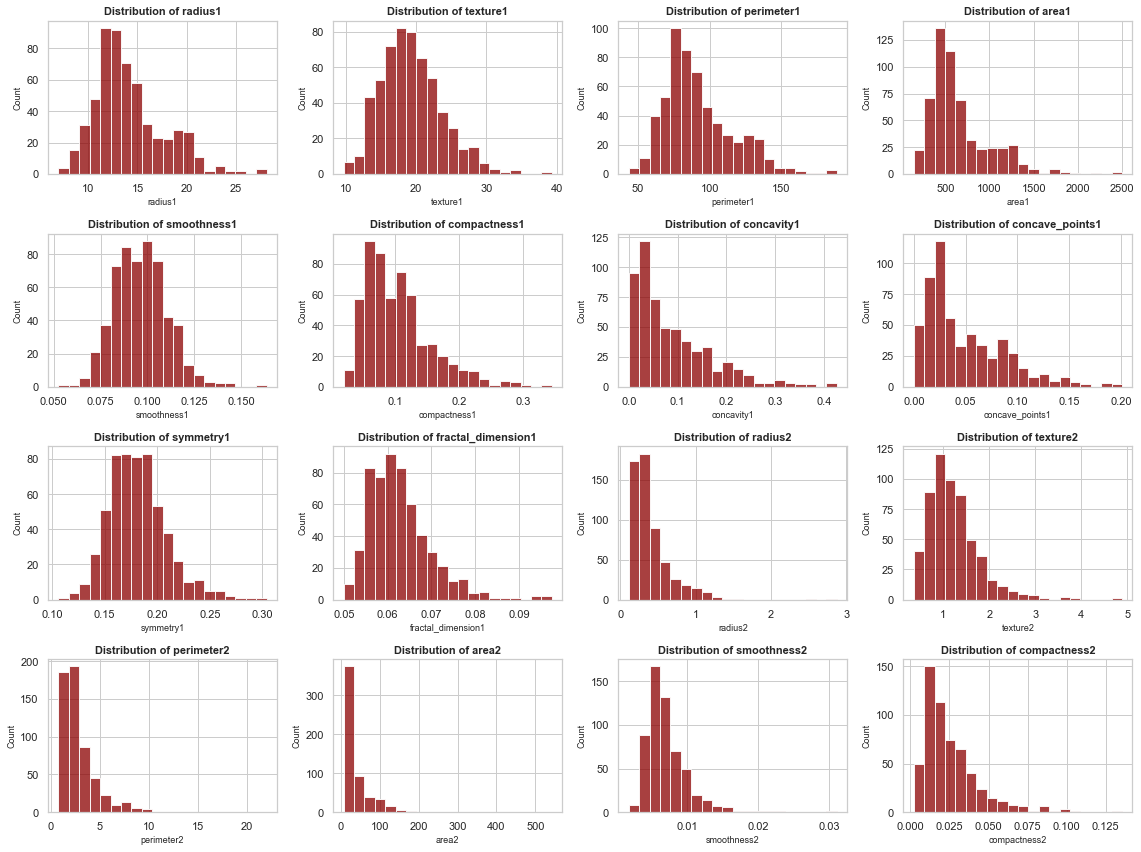

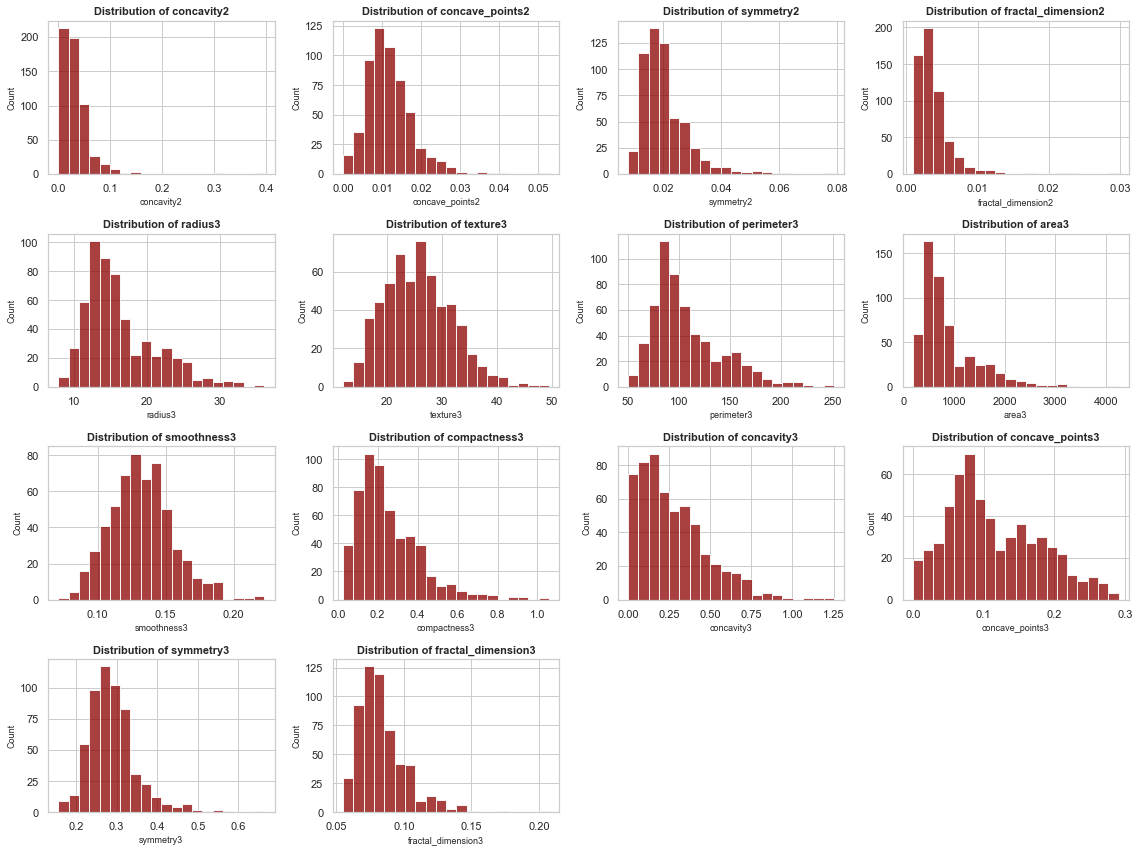

In [34]:
# Select only the 30 numerical feature columns
numerical_cols = df.columns[2:]

sns.set_theme(style="whitegrid")

# --- First 16 features ---
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(numerical_cols[:16]):
  sns.histplot(df[col], kde=False, ax=axes[i], color="darkred", bins=20)
  axes[i].set_title(f"Distribution of {col}", fontsize=11, fontweight="bold")
  axes[i].set_xlabel(col, fontsize=9)
  axes[i].set_ylabel("Count", fontsize=9)

for j in range(i + 1, len(axes)):
  fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# --- Remaining 14 features ---
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(numerical_cols[16:]):
  sns.histplot(df[col], kde=False, ax=axes[i], color="darkred", bins=20)
  axes[i].set_title(f"Distribution of {col}", fontsize=11, fontweight="bold")
  axes[i].set_xlabel(col, fontsize=9)
  axes[i].set_ylabel("Count", fontsize=9)

for j in range(i + 1, len(axes)):
  fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### 4.	 Perform a stratified 70:30 training-testing split. 

In [35]:
X = df.drop(columns=["id", "diagnosis"])
y = df["diagnosis"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

print(f"Training set shape (X_train): {X_train.shape}")
print(f"Testing set shape (X_test): {X_test.shape}")


Training set shape (X_train): (398, 30)
Testing set shape (X_test): (171, 30)


### 5.	Standardize the numerical features using StandardScaler. 

In [36]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print(X_train_scaled.head())

      radius1  texture1  perimeter1     area1  smoothness1  compactness1  concavity1  concave_points1  symmetry1  fractal_dimension1   radius2  texture2  perimeter2     area2  smoothness2  compactness2  concavity2  concave_points2  symmetry2  fractal_dimension2   radius3  texture3  perimeter3     area3  smoothness3  compactness3  concavity3  concave_points3  symmetry3  fractal_dimension3
78   1.705820  1.049745    2.121295  1.669337     2.276458      4.544295    3.539139         2.848393   4.032390            2.639773  1.886582  1.200053    2.872750  1.749217     1.197773      2.415587    2.324706         2.297848   6.944769            0.827408  1.459510  0.949589    1.868176  1.306840     1.335383      2.313855    2.346427         2.049399   3.944281            0.866554
330  0.536388 -0.909945    0.569095  0.390316    -0.065868      0.644945    0.393543         0.557002  -0.116781           -0.401530 -0.250414 -0.844424   -0.118574 -0.161492    -0.376146      0.408546    0.147716     

### 6.	Build a baseline SVM classifier and determine its test accuracy.

In [37]:
svm_baseline = SVC(random_state=42)

svm_baseline.fit(X_train_scaled, y_train)

y_pred = svm_baseline.predict(X_test_scaled)

test_accuracy = accuracy_score(y_test, y_pred)
print(f"\nBaseline SVM Test Accuracy: {test_accuracy * 100:.2f}%")


Baseline SVM Test Accuracy: 95.91%


### 7.	Evaluate the baseline SVM using precision, recall, F1-score, and confusion matrix.

               precision    recall  f1-score   support

   Benign (B)       0.94      1.00      0.97       107
Malignant (M)       1.00      0.89      0.94        64

     accuracy                           0.96       171
    macro avg       0.97      0.95      0.96       171
 weighted avg       0.96      0.96      0.96       171


Confusion Matrix (Rows: True, Columns: Predicted):
[[107   0]
 [  7  57]]


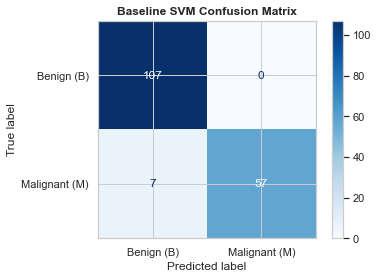

In [38]:
print(classification_report(y_test, y_pred, target_names=["Benign (B)", "Malignant (M)"]))

cm = confusion_matrix(y_test, y_pred, labels=["B", "M"])
print("\nConfusion Matrix (Rows: True, Columns: Predicted):")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm, display_labels=["Benign (B)", "Malignant (M)"]
)
disp.plot(cmap=plt.cm.Blues)
plt.title("Baseline SVM Confusion Matrix", fontsize=12, fontweight="bold")
plt.show()

### 8.	Use GridSearchCV to tune SVM kernel, regularization parameter C, gamma, and polynomial degree. 

In [40]:
param_grid = {
    "kernel": ["linear", "rbf", "poly", "sigmoid"],
    "C": [0.1, 1, 10, 100],
    "gamma": ["scale", "auto", 0.01, 0.1, 1],
    "degree": [2, 3, 4],  # Relevant primarily for the 'poly' kernel
}
svc = SVC(random_state=42)

grid_search = GridSearchCV(
    estimator=svc,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,  
    verbose=1,
)

grid_search.fit(X_train_scaled, y_train)

print("\n--- Best Hyperparameters Found ---")
for param, value in grid_search.best_params_.items():
  print(f"{param}: {value}")

print(
    f"\nBest 5-Fold CV Accuracy: {grid_search.best_score_ * 100:.2f}%"
)

best_svm = grid_search.best_estimator_
test_accuracy = best_svm.score(X_test_scaled, y_test)
print(f"Test Set Accuracy with Tuned Model: {test_accuracy * 100:.2f}%")

Fitting 5 folds for each of 240 candidates, totalling 1200 fits

--- Best Hyperparameters Found ---
C: 10
degree: 2
gamma: scale
kernel: rbf

Best 5-Fold CV Accuracy: 97.22%
Test Set Accuracy with Tuned Model: 97.08%


### 9.	Tabulate and rank the SVM hyperparameter combinations according to cross-validation performance. 

In [41]:
results_df = pd.DataFrame(grid_search.cv_results_)

cols_to_keep = [
    "param_kernel",
    "param_C",
    "param_gamma",
    "param_degree",
    "mean_test_score",
    "std_test_score",
    "rank_test_score",
]

ranked_results = results_df[cols_to_keep].copy()
ranked_results.columns = [
    "Kernel",
    "C",
    "Gamma",
    "Degree",
    "Mean CV Accuracy",
    "Std CV",
    "Rank",
]

ranked_results = ranked_results.sort_values(by="Rank").reset_index(drop=True)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)

print("--- Top 10 SVM Hyperparameter Combinations by CV Performance ---")
print(ranked_results.head(10).to_string(index=False))

--- Top 10 SVM Hyperparameter Combinations by CV Performance ---
Kernel  C Gamma Degree  Mean CV Accuracy   Std CV  Rank
   rbf 10  auto      4          0.972215 0.027066     1
   rbf 10 scale      4          0.972215 0.027066     1
   rbf 10  auto      3          0.972215 0.027066     1
   rbf 10 scale      3          0.972215 0.027066     1
   rbf 10 scale      2          0.972215 0.027066     1
   rbf 10  auto      2          0.972215 0.027066     1
   rbf  1  0.01      2          0.969778 0.017241     7
   rbf  1  0.01      3          0.969778 0.017241     7
   rbf  1  0.01      4          0.969778 0.017241     7
   rbf  1 scale      2          0.969684 0.028457    10


### 10.	Compare the best Linear, Polynomial, and RBF SVM configurations. 

In [42]:
comparison_rows = []
for kernel_name in ["linear", "poly", "rbf"]:
  subset = ranked_results[ranked_results["Kernel"].str.lower() == kernel_name]
  if not subset.empty:
    comparison_rows.append(subset.iloc[0])

comparison_df = pd.DataFrame(comparison_rows)

print("\n--- Best Configuration Comparison: Linear, Polynomial, & RBF ---")
print(comparison_df.to_string(index=False))


--- Best Configuration Comparison: Linear, Polynomial, & RBF ---
Kernel     C Gamma  Degree  Mean CV Accuracy   Std CV  Rank
linear   0.1 scale       4          0.967247 0.018988    19
  poly 100.0  auto       3          0.952057 0.035330   112
   rbf  10.0  auto       4          0.972215 0.027066     1


### 11.	Evaluate the optimal SVM model on the unseen test dataset using accuracy, precision, recall, F1-score, and confusion matrix.

Optimal SVM Test Accuracy: 97.08%

               precision    recall  f1-score   support

   Benign (B)       0.96      0.99      0.98       107
Malignant (M)       0.98      0.94      0.96        64

     accuracy                           0.97       171
    macro avg       0.97      0.96      0.97       171
 weighted avg       0.97      0.97      0.97       171

Confusion Matrix (Rows: True, Columns: Predicted):
[[106   1]
 [  4  60]]


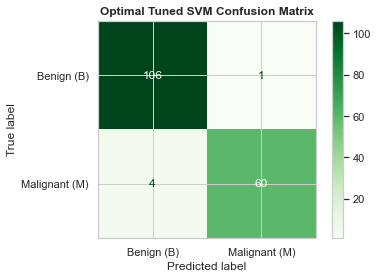

In [43]:
best_svm = grid_search.best_estimator_

y_pred_tuned = best_svm.predict(X_test_scaled)

test_accuracy = accuracy_score(y_test, y_pred_tuned)
print(f"Optimal SVM Test Accuracy: {test_accuracy * 100:.2f}%\n")

print(classification_report(y_test, y_pred_tuned, target_names=["Benign (B)", "Malignant (M)"]))

cm = confusion_matrix(y_test, y_pred_tuned, labels=["B", "M"])
print("Confusion Matrix (Rows: True, Columns: Predicted):")
print(cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Benign (B)", "Malignant (M)"])
disp.plot(cmap=plt.cm.Greens)
plt.title("Optimal Tuned SVM Confusion Matrix", fontsize=12, fontweight="bold")
plt.show()

### 12. Identify the best SVM kernel and comment on why it is suitable for the Breast Cancer Wisconsin dataset.

The RBF kernel effectively models complex, non-linear relationships among cellular features.
It maps data into higher dimensions to cleanly separate overlapping benign and malignant clusters.